# A/B Testing Project: Landing Page Experiment

## 1. Problem Definition
This project analyzes an A/B test conducted to evaluate whether a new landing page leads to a higher conversion rate than the old landing page.

Users were assigned to either a **control group** or a **treatment group**:

- **Control group** → shown the **old landing page**
- **Treatment group** → shown the **new landing page**

The core business question is:

**Should the company replace the old landing page with the new one based on experiment results?**

The primary success metric for this experiment is **conversion rate**, defined as the proportion of users who converted after seeing a landing page.

This analysis will not stop at comparing raw conversion rates. It will also check whether the experiment data is trustworthy, whether the observed difference is statistically reliable, and whether the result is meaningful enough to support a real business decision.

---

## 2. Data Understanding

The dataset contains user-level records from an A/B test experiment. Each row represents an observation associated with a user during the experiment.

### Columns

- **user_id**  
  Unique identifier for a user in the experiment.

- **timestamp**  
  The time at which the user interacted with the landing page.

- **group**  
  Indicates the assigned experiment group:
  - `control` → expected to see the old landing page  
  - `treatment` → expected to see the new landing page

- **landing_page**  
  The actual landing page shown to the user:
  - `old_page`
  - `new_page`

- **converted**  
  Binary indicator of whether the user converted:
  - `1` → converted  
  - `0` → did not convert  

### Initial Observations and Risks

At first glance, this appears to be a standard A/B testing dataset. However, there are several potential risks that must be validated before any analysis:

- The **unit of analysis** is assumed to be the user, but this must be verified (users may appear multiple times).
- The **group assignment and landing page exposure may not always match**, which would indicate experiment contamination.
- The presence of timestamps suggests possible **time-based effects or logging inconsistencies**.

These risks must be addressed before performing any statistical inference to ensure the validity of the experiment.

---

## 3. Setup

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Load dataset
df = pd.read_csv("../data/raw/ab_data.csv")


df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## 4. Initial Data Inspection

In [2]:
# Shape of dataset
print("Shape:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Basic preview
print("\nFirst few rows:")
display(df.head())

Shape: (294478, 5)

Data types:
user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

Missing values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

First few rows:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## 5. Experiment Integrity Validation

In [5]:
#Define Valid Assignments
valid_control = (df["group"] == "control") & (df["landing_page"] =="old_page")
valid_treatment = (df["group"] == "treatment") & (df["landing_page"] =="new_page")

#flag mismatches
df["is_mismatch"] = ~(valid_control | valid_treatment)

# Summary numbers
total_rows = len(df)
mismatch_rows=df["is_mismatch"].sum()
mismatch_rate=mismatch_rows/total_rows

print("Total rows:", total_rows)
print("Mismatch rows:", mismatch_rows)
print("Mismatch rate (%):", round(mismatch_rate * 100, 4))

# Cross-tab view
print("\nGroup vs Landing Page:")
print(pd.crosstab(df["group"], df["landing_page"]))

# Breakdown of mismatches
print("\nMismatch breakdown:")
print(
    df[df["is_mismatch"]]
    .groupby(["group", "landing_page"])
    .size()
    .reset_index(name="count")
)


Total rows: 294478
Mismatch rows: 3893
Mismatch rate (%): 1.322

Group vs Landing Page:
landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965

Mismatch breakdown:
       group landing_page  count
0    control     new_page   1928
1  treatment     old_page   1965


## 6. Data Cleaning 

The dataset contains a small number of mismatched rows where the assigned group does not align with the landing page shown.

Since these rows violate the fundamental structure of the A/B test, they are excluded from the analysis.

The mismatch rate is approximately **1.32%**, which is small and does not indicate a systematic bias, as mismatches are nearly symmetric across groups.

To preserve the validity of the experiment, only rows with consistent group and landing page assignments are retained.

In [7]:
#Keep only valid rows
df_clean=df[~df["is_mismatch"]].copy()

#sanity check
print("Cleaned Dataset Shape:",df_clean.shape)

valid_control = (df_clean["group"] == "control") & (df_clean["landing_page"] == "old_page")
valid_treatment = (df_clean["group"] == "treatment") & (df_clean["landing_page"] == "new_page")

print("Remaining mismatches:", (~(valid_control | valid_treatment)).sum())

Cleaned Dataset Shape: (290585, 6)
Remaining mismatches: 0


## 7. User-Level Validation

In [9]:
#Total unique users
unique_users=df_clean["user_id"].nunique()
total_rows=len(df_clean)

print("Total rows:", total_rows)
print("Unique users:", unique_users)

#check duplicates
duplicated_users = df_clean["user_id"].value_counts()
duplicated_users = duplicated_users[duplicated_users > 1]

print("\nNumber of users appearing more than once:", len(duplicated_users))
print("Total duplicate rows (beyond first occurrence):", duplicated_users.sum() - len(duplicated_users))

# Preview some duplicates
duplicated_users.head()



Total rows: 290585
Unique users: 290584

Number of users appearing more than once: 1
Total duplicate rows (beyond first occurrence): 1


user_id
773192    2
Name: count, dtype: int64


The dataset is expected to represent one observation per user.

A check on user_id revealed that almost all users appear only once, with only a single user appearing twice.

Since duplicate observations violate the assumption of independent observations in A/B testing, one occurrence of the duplicate user is removed.

Given that this affects only one user, the impact on the overall analysis is negligible.



In [10]:
# Remove duplicate users, keep first occurrence
df_clean = df_clean.drop_duplicates(subset="user_id", keep="first")

# Verify
print("Rows after removing duplicates:", len(df_clean))
print("Unique users after cleaning:", df_clean["user_id"].nunique())

Rows after removing duplicates: 290584
Unique users after cleaning: 290584


## 8. Metric Definition

The primary metric for this experiment is the **conversion rate**.

Conversion rate is defined as:

> number of users who converted / total number of users in a group

This metric directly reflects the effectiveness of a landing page in driving user conversions.

Since the goal of the experiment is to determine whether the new landing page performs better than the old one, conversion rate serves as the most appropriate measure of success.

It is important to distinguish between:

- **Statistical significance** → whether the observed difference is likely due to chance  
- **Practical significance** → whether the difference is large enough to matter from a business perspective  

Both aspects will be considered in the final decision.

In [11]:
# Conversion rate by group
conversion_rates = df_clean.groupby('group')["converted"].mean()

print("conversion Rate:")
print(conversion_rates)

#Group sizes
group_sizes = df_clean.groupby("group")["user_id"].count()

print("\nGroup Sizes")
print(group_sizes)

conversion Rate:
group
control      0.120386
treatment    0.118808
Name: converted, dtype: float64

Group Sizes
group
control      145274
treatment    145310
Name: user_id, dtype: int64


## 9. Exploratory Analysis

### Conversion Rate Comparison

The observed conversion rates for the two groups are:

- ***Control group: ~12.04%***
- ***Treatment group: ~11.88%***

At a surface level, the treatment group appears to have a slightly lower conversion rate than the control group.

However, the observed difference is small (~0.16 percentage points), and this alone is not sufficient to conclude that the new landing page performs worse.

This difference may be due to random variation in the sample rather than a true underlying effect.

A formal statistical test is required to determine whether this observed difference is statistically significant.

In [12]:
# Absolute difference in conversion rate
diff = conversion_rates["treatment"] - conversion_rates["control"]

print("Observed Difference (Treatment - Control):", diff)

Observed Difference (Treatment - Control): -0.0015782389853555567


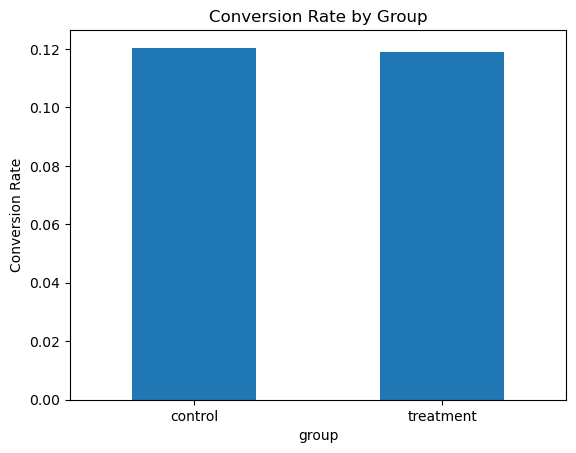

In [17]:
import matplotlib.pyplot as plt

# Bar plot
conversion_rates.plot(kind='bar')

plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

### Conversion Rate Visualization

- The bar chart compares the conversion rates of the control and treatment groups.
- While the control group shows a slightly higher conversion rate than the treatment group, the difference is very small and not sufficient to draw conclusions without statistical testing.

---
---

### Optional: Time-Based Analysis

To check whether the treatment effect varies over time, conversion rates can be analyzed across different time periods.

This helps identify potential novelty effects or temporal drift in user behavior.

However, given the large sample size and consistently small observed effect, this analysis is exploratory and does not materially impact the overall conclusion.

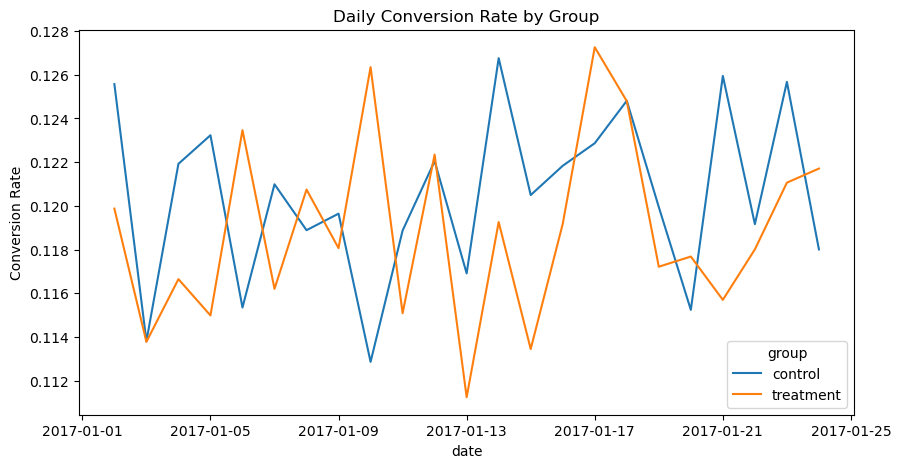

In [22]:
# Convert timestamp
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

# Extract date
df_clean["date"] = df_clean["timestamp"].dt.date

# Daily conversion rates
daily_conversion = (
    df_clean.groupby(["date", "group"])["converted"]
    .mean()
    .unstack()
)

daily_conversion.plot(figsize=(10,5))
plt.title("Daily Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()

### Time-Based Analysis Interpretation

- The daily conversion rate plot shows fluctuations in both control and treatment groups over time.

- However, there is no consistent pattern where the treatment group outperforms the control group. The conversion rates for both groups vary around similar levels, and the lines frequently cross each other.

- This suggests that the observed differences are likely due to random variation rather than a systematic time-based effect.

- Therefore, the time-based analysis does not provide additional evidence that the new landing page improves conversion rate.

---
---

## 10. Statistical Inference

### Hypothesis Definition

The goal of this experiment is to determine whether the new landing page leads to a higher conversion rate than the old landing page.

Let:

- ***p_control = conversion rate of the control group (old page)***  
- ***p_treatment = conversion rate of the treatment group (new page)***

The hypotheses are defined as:

- ***Null hypothesis (H₀): p_treatment ≤ p_control***
- ***Alternative hypothesis (H₁): p_treatment > p_control***  

The null hypothesis assumes that the new page does not improve conversion rate, while the alternative hypothesis tests whether the new page provides a positive lift.

This is a one-sided test because the business decision depends specifically on whether the new page performs better than the old page.

---

---

### Test Selection

To evaluate the difference in conversion rates between the control and treatment groups, a **two-proportion z-test** is used.

This test is appropriate because:

- The outcome variable (converted) is binary
- We are comparing proportions between two independent groups
- The sample size is large, allowing the use of normal approximation

### Assumptions

The validity of the two-proportion z-test depends on the following assumptions:

1. **Independence of observations**  
   Each user appears only once in the dataset, satisfying independence.

2. **Sufficiently large sample size**  
   Both groups have large sample sizes (~145k users), ensuring that the sampling distribution of the proportion is approximately normal.

3. **Random assignment**  
   It is assumed that users were randomly assigned to control and treatment groups.

Given that these assumptions are reasonably satisfied, the two-proportion z-test is suitable for this analysis.

---

In [13]:
df.head()

,user_id,timestamp,group,landing_page,converted,is_mismatch
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,False
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,False
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,False
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,False
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,False


In [14]:
from statsmodels.stats.proportion import proportions_ztest

# Number of conversions

conversions = df_clean.groupby("group")["converted"].sum()

# Number of Users

n_users= df_clean.groupby("group")["converted"].count()

# Arrange in correct order:[treatment, control]
count = [conversions["treatment"],conversions["control"]]
nobs = [n_users["treatment"], n_users["control"]]

# Perform one-sided z-test (alternative = 'larger')
z_stat,p_value=proportions_ztest(count,nobs,alternative='larger')

print("Z-statistics:",z_stat)
print("P-value:",p_value)

Z-statistics: -1.3109241984234394
P-value: 0.9050583127590245


### Hypothesis Test Result

A one-sided two-proportion z-test was conducted to evaluate whether the new landing page achieves a higher conversion rate than the old landing page.

Test result:

- ***z-statistic = -1.3109***
- ***p-value = 0.9051***

Since the p-value is much larger than a typical significance level such as **0.05**, the null hypothesis cannot be rejected.

This means the experiment does **not provide sufficient evidence** that the new landing page improves conversion rate compared with the old landing page.

It is also important to interpret this result carefully:

- The result does **not** prove that the new page is better
- The result does **not** prove that both pages are exactly the same
- The result only indicates that the observed data does not support the claim that the new page increases conversions

In [15]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: there is sufficient evidence that the treatment page performs better.")
else:
    print("Fail to reject H0: there is insufficient evidence that the treatment page performs better.")

Fail to reject H0: there is insufficient evidence that the treatment page performs better.


### Confidence Interval Estimation

While the hypothesis test indicates whether there is sufficient evidence of an improvement, it does not quantify the magnitude of the effect.

To understand the possible range of the true difference in conversion rates, a 95% confidence interval is computed for:

> (conversion rate of treatment - conversion rate of control)

This interval provides a range of plausible values for the true effect and helps assess both statistical and practical significance.

In [16]:
import numpy as np

# Conversion rates
p_control = conversion_rates["control"]
p_treatment = conversion_rates["treatment"]

# Sample sizes
n_control = group_sizes["control"]
n_treatment = group_sizes["treatment"]

# Difference
diff = p_treatment - p_control

# Standard error
se = np.sqrt(
    (p_control * (1 - p_control) / n_control) +
    (p_treatment * (1 - p_treatment) / n_treatment)
)

# 95% CI
z_critical = 1.96

ci_lower = diff - z_critical * se
ci_upper = diff + z_critical * se

print("Difference (Treatment - Control):", diff)
print("95% Confidence Interval:", (ci_lower, ci_upper))

Difference (Treatment - Control): -0.0015782389853555567
95% Confidence Interval: (-0.003937903604443846, 0.0007814256337327326)


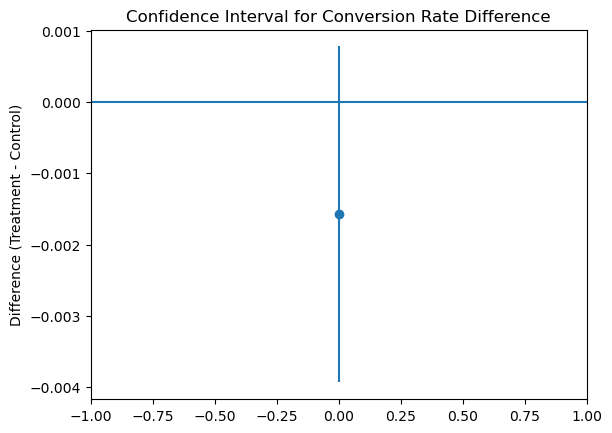

In [18]:
# CI visualization
plt.figure()

plt.errorbar(
    x=0,
    y=diff,
    yerr=1.96 * se,
    fmt='o'
)

plt.axhline(0)  # zero effect line
plt.title("Confidence Interval for Conversion Rate Difference")
plt.ylabel("Difference (Treatment - Control)")
plt.xlim(-1, 1)

plt.show()

### Confidence Interval Interpretation

- The confidence interval visualizes the uncertainty around the observed difference in conversion rates.
- The vertical line represents the estimated difference, and the interval shows the range of plausible values for the true effect.
- Since the interval crosses zero, it indicates that there is no clear evidence of a positive or negative effect.
- This supports the conclusion that the new landing page does not produce a statistically or practically meaningful improvement.

---
---

## 11. Experiment Sensitivity (Power / MDE)

A non-significant result does not automatically mean that the treatment has no useful effect. It is also important to understand whether the experiment was capable of detecting a meaningful uplift if one truly existed.

To assess this, a power-based minimum detectable effect (MDE) analysis is performed.

The MDE represents the smallest difference in conversion rate that this experiment could reliably detect, given:

- the observed sample size
- the baseline conversion rate
- a significance level of 0.05
- a target power of 0.80

This helps determine whether the experiment was sufficiently sensitive for decision-making.

In [20]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Baseline conversion rate from control
p1 = conversion_rates["control"]

# Use the smaller group size for a conservative estimate
n_per_group = min(group_sizes["control"], group_sizes["treatment"])

alpha = 0.05
power = 0.80

analysis = NormalIndPower()

# Solve for Cohen's h effect size
effect_size = analysis.solve_power(
    nobs1=n_per_group,
    alpha=alpha,
    power=power,
    ratio=1.0,
    alternative="larger"
)

# Convert effect size into detectable treatment rate
# h = 2*asin(sqrt(p2)) - 2*asin(sqrt(p1))
# We'll solve numerically for p2
import numpy as np

def cohens_h(p_a, p_b):
    return 2 * np.arcsin(np.sqrt(p_b)) - 2 * np.arcsin(np.sqrt(p_a))

candidate_ps = np.linspace(p1, min(p1 + 0.05, 0.999999), 100000)
h_values = np.abs(cohens_h(p1, candidate_ps))
p2_mde = candidate_ps[np.argmin(np.abs(h_values - effect_size))]

absolute_mde = p2_mde - p1
relative_mde = absolute_mde / p1

print("Baseline conversion rate (control):", p1)
print("Users per group used for power calculation:", n_per_group)
print("Required Cohen's h effect size:", effect_size)
print("Approx detectable treatment conversion rate:", p2_mde)
print("Absolute MDE:", absolute_mde)
print("Relative MDE (% lift over baseline):", relative_mde * 100)

Baseline conversion rate (control): 0.1203863045004612
Users per group used for power calculation: 145274
Required Cohen's h effect size: 0.00922589758201357
Approx detectable treatment conversion rate: 0.12340483468576305
Absolute MDE: 0.0030185301853018487
Relative MDE (% lift over baseline): 2.507370084850711


### MDE Interpretation

The minimum detectable effect (MDE) analysis shows that, given the sample size and baseline conversion rate, this experiment was powered to reliably detect an uplift of approximately:

- **0.30 percentage points** in absolute conversion rate
- **2.51% relative lift** over the control baseline

This means the experiment was reasonably sensitive to moderate improvements in conversion rate.

Since the observed treatment effect was much smaller than this threshold and was directionally negative, the experiment does not support the claim that the new landing page delivers a meaningful improvement.

A very small positive effect below the MDE cannot be ruled out entirely. However, such an effect would likely be too small to justify deployment unless the business considers even tiny gains meaningful.

---
---

### Practical Significance Threshold

Statistical significance alone is not enough to justify deployment. Even if an uplift is real, it must still be large enough to matter from a business perspective.

For this project, a **1% relative lift in conversion rate** is used as an illustrative threshold for practical significance.

Given the control conversion rate of approximately 12.04%, a 1% relative lift corresponds to an absolute improvement of roughly:

> 0.1204 × 0.01 ≈ 0.0012

This means that an absolute increase of about **0.12 percentage points** would be treated as the minimum practically meaningful improvement.

This threshold is not directly provided by the dataset and should be interpreted as a reasonable business assumption for decision-making.

In [21]:
control_rate = conversion_rates["control"]

practical_relative_threshold = 0.01  # 1% relative lift
practical_absolute_threshold = control_rate * practical_relative_threshold

print("Control conversion rate:", control_rate)
print("Practical threshold (relative):", practical_relative_threshold * 100, "%")
print("Practical threshold (absolute):", practical_absolute_threshold)

Control conversion rate: 0.1203863045004612
Practical threshold (relative): 1.0 %
Practical threshold (absolute): 0.0012038630450046121


>## 11. Business Interpretation

This analysis evaluates whether the new landing page leads to a meaningful improvement in conversion rate compared to the existing page.

>> ### Observed Performance

The observed conversion rates are:

- Control group: ~12.04%
- Treatment group: ~11.88%

The treatment group shows a slightly lower conversion rate, with an observed difference of approximately **-0.16 percentage points**.

>> ### Statistical Evidence

A one-sided two-proportion z-test was conducted to evaluate whether the new page improves conversion rate.

- z-statistic = -1.31  
- p-value = 0.905  

The p-value is far above a typical significance level of 0.05, indicating that there is **no statistical evidence** that the new landing page performs better than the existing one.

>> ### Confidence Interval

The 95% confidence interval for the difference in conversion rate is:

(-0.00394, 0.00078)

This interval includes zero, meaning the true effect could be slightly negative or slightly positive.

However, even in the most optimistic scenario, the potential improvement is extremely small (~0.08 percentage points).

>> ### Practical Significance

A minimum practical threshold of **1% relative lift** was defined, corresponding to an absolute improvement of approximately **0.00120 (0.12 percentage points)**.

The confidence interval does **not reach this threshold**, indicating that even plausible positive effects are too small to be meaningful from a business perspective.

>> ### Experiment Sensitivity (Power / MDE)

The experiment was capable of detecting an uplift of approximately:

- **0.30 percentage points (absolute)**  
- **2.51% relative lift**

Since no such effect was observed, the lack of statistical significance is **not due to insufficient sample size** for moderate improvements.

>## Final Decision

Based on all evidence:

- There is no statistical support for the new page being better  
- The observed effect is small and directionally negative  
- Even the upper bound of the confidence interval is below the practical threshold  
- The experiment was sufficiently powered to detect meaningful improvements  

**Conclusion:**  
The new landing page does **not provide a meaningful improvement** and should **not be deployed**. The existing landing page should be retained unless a stronger variation is developed and tested.

##  Recommended Next Steps

The experiment results suggest that the new landing page does not provide a meaningful improvement in conversion rate. However, this does not conclude the optimization process. Instead, it informs the next set of actions.

### 1. Test more substantial design changes

The current experiment indicates that the tested variation likely does not introduce a strong enough change to influence user behavior. Future experiments should focus on more impactful modifications rather than minor variations.

### 2. Explore user segmentation

The overall effect may hide differences across user segments. Further analysis could examine whether certain groups (e.g., new vs returning users, device types) respond differently to the new design.

### 3. Refine hypotheses

Future experiments should be based on more specific hypotheses about user behavior. For example, instead of broadly testing a new page, focus on elements such as call-to-action placement, messaging clarity, or visual hierarchy.

### 4. Align experiments with expected impact

Before running future experiments, define a clear expected uplift and ensure the experiment is designed with sufficient power to detect that effect. This will help avoid inconclusive results and improve decision-making.

### 5. Consider additional metrics

Conversion rate alone may not capture the full impact of the landing page. Future analyses could incorporate other metrics such as engagement, retention, or revenue to provide a more comprehensive evaluation.